<a href="https://colab.research.google.com/github/SureshRajpoot143/AWS_workshop/blob/main/Travel_Approval_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travel Reimbursement Approval Agent

---------------------------

### **AI Developer Assignment — GenAI + Agentic Workflow**



**Name**:**Akshat Mishra**


**Model used:** Groq — llama-3.3-70b-versatile


**Approach:** Tool-first checks (Python functions) → LLM reasons over tool results → structured JSON decision


**How to run:** Run all cells top to bottom. You'll be asked to paste your Groq API key when prompted (kept private, not stored in the notebook).

-----

# **Step-1:Install Depedencies**

In [ ]:
! pip install groq pandas seaborn matplotlib -q

## **Step-2:Import libraires**

In [ ]:
import json
import getpass
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from groq import Groq

print("Libraries loaded successfully")

Libraries loaded successfully


## **Step 3: Groq API Setup**



In [ ]:
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

client = Groq(api_key=GROQ_API_KEY)

MODEL_NAME = "llama-3.3-70b-versatile"

print("Groq client initialized with model:", MODEL_NAME)

Groq client initialized with model: llama-3.3-70b-versatile


## **Step 4: Quick Test — Confirm API is Working**

In [ ]:
test_response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Reply with exactly: API working"}],
    max_tokens=10
)

print(test_response.choices[0].message.content)

API working


## **Step 5: Policy Data (Appendix A)**

Stored as a Python dictionary. Each rule has a stable `POL-*` id so the agent can cite it in its explanation.

In [ ]:
POLICY = {

    "POL-CAT-01": "Eligible categories: airfare (economy only), lodging, meals (per-diem capped), ground transport, conference/registration fees.",
    "POL-CAT-02": "Ineligible categories (never reimbursable): alcohol/minibar, spa/gym/entertainment, in-room movies, personal shopping/gifts, traffic fines, any personal expense.",
    "POL-PD-01": "Meals: max $75 per day. Amount above cap is deducted.",
    "POL-PD-02": "Lodging: max $200 per night. Amount above cap is deducted.",
    "POL-PD-03": "Ground transport: max $50 per day. Amount above cap is deducted.",
    "POL-AIR-01": "Only economy class airfare is reimbursable. Business/first class is a policy exception -> Manual Review.",
    "POL-RCT-01": "Receipt required for any single line item > $25. Airfare and lodging always require a receipt regardless of amount.",
    "POL-RCT-02": "If a required receipt is missing, do NOT auto-reject -> route to Manual Review.",
    "POL-APR-01": "Auto-approve tier: total <= $500, if fully compliant.",
    "POL-APR-02": "Manager tier: total > $500 and <= $2000, approvable if fully compliant.",
    "POL-APR-03": "Director tier: total > $2000 -> exceeds auto-approval authority -> Manual Review.",
    "POL-TIME-01": "Claims must be submitted within 30 days of expense date. Late claims -> Manual Review."
}

print(f"Loaded {len(POLICY)} policy rules")
for k, v in POLICY.items():
    print(f"{k}: {v}")

Loaded 12 policy rules
POL-CAT-01: Eligible categories: airfare (economy only), lodging, meals (per-diem capped), ground transport, conference/registration fees.
POL-CAT-02: Ineligible categories (never reimbursable): alcohol/minibar, spa/gym/entertainment, in-room movies, personal shopping/gifts, traffic fines, any personal expense.
POL-PD-01: Meals: max $75 per day. Amount above cap is deducted.
POL-PD-02: Lodging: max $200 per night. Amount above cap is deducted.
POL-PD-03: Ground transport: max $50 per day. Amount above cap is deducted.
POL-AIR-01: Only economy class airfare is reimbursable. Business/first class is a policy exception -> Manual Review.
POL-RCT-01: Receipt required for any single line item > $25. Airfare and lodging always require a receipt regardless of amount.
POL-RCT-02: If a required receipt is missing, do NOT auto-reject -> route to Manual Review.
POL-APR-01: Auto-approve tier: total <= $500, if fully compliant.
POL-APR-02: Manager tier: total > $500 and <= $200

## **Step 6: Sample Claims (Appendix B)**

Stored as a list of dictionaries — one per claim, with itemized line items.

In [ ]:
CLAIMS = [
    {
        "claim_id": "CLM-001",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt": True, "class": "economy"},
            {"category": "lodging", "description": "Hotel, 2 nights", "amount": 360.00, "receipt": True, "nights": 2},
            {"category": "meals", "description": "Meals, 3 days", "amount": 180.00, "receipt": True, "days": 3},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-002",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-003",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt": True, "class": "economy"},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt": True, "nights": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt": True, "days": 2}
        ]
    },
    {
        "claim_id": "CLM-004",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt": True, "class": "business"},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt": False, "nights": 3}
        ]
    },
    {
        "claim_id": "CLM-005",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt": True, "days": 1}
        ]
    }
]

print(f"Loaded {len(CLAIMS)} claims")
for c in CLAIMS:
    print(c["claim_id"], "-", len(c["items"]), "items")

Loaded 5 claims
CLM-001 - 4 items
CLM-002 - 2 items
CLM-003 - 3 items
CLM-004 - 2 items
CLM-005 - 1 items


## **Step 7: Tool Functions**

These are the "tools" the agent will call. Each does ONE simple, testable check.
The agent (LLM) will use the *results* of these functions to make its final decision — it does not guess these numbers itself.

In [ ]:
def check_receipt(item):
    """
    Tool 1: Checks if a required receipt is missing.
    Rule: POL-RCT-01 (receipt required if amount > $25, or category is airfare/lodging)
    """
    requires_receipt = item["amount"] > 25 or item["category"] in ["airfare", "lodging"]
    missing = requires_receipt and not item.get("receipt", False)
    return {
        "category": item["category"],
        "requires_receipt": requires_receipt,
        "receipt_missing": missing,
        "policy_ref": "POL-RCT-01" if not missing else "POL-RCT-02"
    }

In [ ]:
def check_per_diem(item):
    """
    Tool 2: Checks if amount exceeds category-specific daily/nightly cap.
    Rules: POL-PD-01 (meals $75/day), POL-PD-02 (lodging $200/night), POL-PD-03 (transport $50/day)
    """
    caps = {"meals": 75, "lodging": 200, "ground_transport": 50}
    category = item["category"]

    if category not in caps:
        return {"category": category, "applicable": False}

    units = item.get("days") or item.get("nights") or 1
    cap_total = caps[category] * units
    excess = max(0, item["amount"] - cap_total)

    return {
        "category": category,
        "applicable": True,
        "cap_total": cap_total,
        "claimed_amount": item["amount"],
        "excess_amount": excess,
        "within_limit": excess == 0,
        "policy_ref": f"POL-PD-0{list(caps.keys()).index(category)+1}"
    }

In [ ]:
def check_category_eligibility(item):
    """
    Tool 3: Checks if the category is eligible or banned outright.
    Rules: POL-CAT-01 (eligible), POL-CAT-02 (ineligible)
    """
    eligible = ["airfare", "lodging", "meals", "ground_transport", "conference_fees"]
    ineligible = ["spa", "minibar", "gym", "entertainment", "personal_shopping", "gifts", "fines"]

    category = item["category"]
    if category in ineligible:
        return {"category": category, "eligible": False, "policy_ref": "POL-CAT-02"}
    elif category in eligible:
        # extra check: business class airfare is a policy exception
        if category == "airfare" and item.get("class") == "business":
            return {"category": category, "eligible": "exception", "policy_ref": "POL-AIR-01"}
        return {"category": category, "eligible": True, "policy_ref": "POL-CAT-01"}
    else:
        return {"category": category, "eligible": "unknown", "policy_ref": None}

In [ ]:
def check_approval_tier(total_amount):
    """
    Tool 4: Checks which approval tier the total claim falls into.
    Rules: POL-APR-01 (<=500 auto), POL-APR-02 (500-2000 manager), POL-APR-03 (>2000 director/manual)
    """
    if total_amount <= 500:
        return {"tier": "auto_approve", "policy_ref": "POL-APR-01"}
    elif total_amount <= 2000:
        return {"tier": "manager_approve", "policy_ref": "POL-APR-02"}
    else:
        return {"tier": "manual_review_required", "policy_ref": "POL-APR-03"}

In [ ]:
from datetime import datetime

def check_timeliness(trip_end, submitted):
    """
    Tool 5: Checks if claim was submitted within 30 days of trip end.
    Rule: POL-TIME-01
    """
    trip_date = datetime.strptime(trip_end, "%Y-%m-%d")
    submit_date = datetime.strptime(submitted, "%Y-%m-%d")
    days_late = (submit_date - trip_date).days

    return {
        "days_after_trip": days_late,
        "within_window": days_late <= 30,
        "policy_ref": "POL-TIME-01"
    }

In [ ]:
# Quick sanity test on CLM-003's lodging item (should exceed $200/night cap)
test_item = CLAIMS[2]["items"][1]
print("Testing item:", test_item)
print("Receipt check:", check_receipt(test_item))
print("Per-diem check:", check_per_diem(test_item))
print("Eligibility check:", check_category_eligibility(test_item))

Testing item: {'category': 'lodging', 'description': 'Hotel, 2 nights @ $250', 'amount': 500.0, 'receipt': True, 'nights': 2}
Receipt check: {'category': 'lodging', 'requires_receipt': True, 'receipt_missing': False, 'policy_ref': 'POL-RCT-01'}
Per-diem check: {'category': 'lodging', 'applicable': True, 'cap_total': 400, 'claimed_amount': 500.0, 'excess_amount': 100.0, 'within_limit': False, 'policy_ref': 'POL-PD-02'}
Eligibility check: {'category': 'lodging', 'eligible': True, 'policy_ref': 'POL-CAT-01'}


## **Step 8: Agent Orchestration Function**

This is the core "agentic" part. For each claim, the function:

1. Runs all tool functions on every item (this is deterministic, reliable math — not left to the LLM)

2. Packages the claim + policy + tool results into a prompt

3. Sends it to Groq (LLM) which reasons over the results and returns the final structured decision


The LLM is told: "prefer Manual Review when unsure" — matching the policy's guidance.

In [ ]:
def run_tools_on_claim(claim):
    """
    Runs all applicable tools on every item in a claim.
    Returns a dictionary of tool results to pass to the LLM.
    """
    total_amount = sum(item["amount"] for item in claim["items"])

    item_results = []
    for item in claim["items"]:
        item_results.append({
            "item": item,
            "receipt_check": check_receipt(item),
            "per_diem_check": check_per_diem(item),
            "eligibility_check": check_category_eligibility(item)
        })

    approval_tier = check_approval_tier(total_amount)
    timeliness = check_timeliness(claim["trip_end"], claim["submitted"])

    return {
        "total_claimed": total_amount,
        "item_results": item_results,
        "approval_tier": approval_tier,
        "timeliness": timeliness,
        "tools_used": ["check_receipt", "check_per_diem", "check_category_eligibility",
                        "check_approval_tier", "check_timeliness"]
    }

In [ ]:
AGENT_SYSTEM_PROMPT = """You are a Travel Reimbursement Approval Agent.

You will be given:
1. The company travel policy (with POL-* rule ids)
2. A claim submitted by an employee
3. Pre-computed tool results (receipt checks, per-diem checks, eligibility checks, approval tier, timeliness)

Your job: combine the tool results into ONE final decision for this claim.

Decision rules:
- APPROVE: every item eligible, all receipts present, all within per-diem, total within approvable tier.
- PARTIAL_APPROVE: claim is valid but some amounts exceed per-diem caps -> reimburse up to cap, deduct excess.
- REJECT: claimed items are ineligible (banned category) with nothing reimbursable.
- MANUAL_REVIEW: any ambiguity, policy exception (e.g. business class airfare), missing required receipt,
  total exceeds director tier, or late submission. PREFER MANUAL_REVIEW OVER FORCING A DECISION.

Respond with ONLY valid JSON (no markdown, no explanation outside the JSON) in exactly this format:
{
  "decision": "APPROVE | PARTIAL_APPROVE | REJECT | MANUAL_REVIEW",
  "approved_amount": <number>,
  "deducted_amount": <number>,
  "missing_docs": [<list of strings>],
  "policy_refs": [<list of POL-* ids used>],
  "confidence": <number between 0 and 1>,
  "explanation": "<short 1-2 sentence explanation>"
}
"""

def run_agent_on_claim(claim):
    """
    Runs tools, then sends everything to the LLM to get the final decision.
    """
    tool_results = run_tools_on_claim(claim)

    user_prompt = f"""
POLICY:
{json.dumps(POLICY, indent=2)}

CLAIM:
{json.dumps(claim, indent=2)}

TOOL RESULTS:
{json.dumps(tool_results, indent=2, default=str)}

Based on the above, return the final decision JSON as instructed.
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": AGENT_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2,
        response_format={"type": "json_object"}
    )

    llm_output = json.loads(response.choices[0].message.content)

    # Combine LLM decision with claim_id and tools_used for final structured output
    final_result = {
        "claim_id": claim["claim_id"],
        "decision": llm_output.get("decision", "MANUAL_REVIEW"),
        "approved_amount": llm_output.get("approved_amount", 0),
        "deducted_amount": llm_output.get("deducted_amount", 0),
        "missing_docs": llm_output.get("missing_docs", []),
        "policy_refs": llm_output.get("policy_refs", []),
        "confidence": llm_output.get("confidence", 0.5),
        "explanation": llm_output.get("explanation", ""),
        "tools_used": tool_results["tools_used"]
    }

    return final_result

# testing

In [ ]:
# Test the agent on just CLM-001 before running all 5
test_result = run_agent_on_claim(CLAIMS[0])
print(json.dumps(test_result, indent=2))

{
  "claim_id": "CLM-001",
  "decision": "MANUAL_REVIEW",
  "approved_amount": 0,
  "deducted_amount": 0,
  "missing_docs": [],
  "policy_refs": [
    "POL-CAT-01",
    "POL-RCT-01",
    "POL-PD-01",
    "POL-PD-02",
    "POL-APR-02"
  ],
  "confidence": 0.8,
  "explanation": "Total claim exceeds auto-approval tier, requires manager approval.",
  "tools_used": [
    "check_receipt",
    "check_per_diem",
    "check_category_eligibility",
    "check_approval_tier",
    "check_timeliness"
  ]
}


## **Step 9: Run Agent on All 5 Claims**

In [ ]:
results = []

for claim in CLAIMS:
    print(f"Processing {claim['claim_id']}...")
    result = run_agent_on_claim(claim)
    results.append(result)
    print(f"  -> Decision: {result['decision']} | Confidence: {result['confidence']}")

print("\nAll 5 claims processed.")

Processing CLM-001...
  -> Decision: MANUAL_REVIEW | Confidence: 0.8
Processing CLM-002...
  -> Decision: REJECT | Confidence: 1
Processing CLM-003...
  -> Decision: PARTIAL_APPROVE | Confidence: 0.9
Processing CLM-004...
  -> Decision: MANUAL_REVIEW | Confidence: 0.8
Processing CLM-005...
  -> Decision: PARTIAL_APPROVE | Confidence: 0.9

All 5 claims processed.


## **Step 10: Final Structured Output (Required Deliverable)**

This is the required final JSON array — one object per claim, exact fields as specified in the assignment.

In [ ]:
# FINAL STRUCTURED OUTPUT — one object per claim
print(json.dumps(results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "MANUAL_REVIEW",
    "approved_amount": 0,
    "deducted_amount": 0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-RCT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-APR-02"
    ],
    "confidence": 0.8,
    "explanation": "Total claim exceeds auto-approval tier, requires manager approval.",
    "tools_used": [
      "check_receipt",
      "check_per_diem",
      "check_category_eligibility",
      "check_approval_tier",
      "check_timeliness"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0,
    "deducted_amount": 0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 1,
    "explanation": "Claimed items are ineligible (spa and minibar) with nothing reimbursable.",
    "tools_used": [
      "check_receipt",
      "check_per_diem",
      "check_category_eligibility",
      "check_approval_tier",
      "check_timeliness"

## Step 11: Dashboard — Results Visualization

Summary of all 5 claim decisions using a table and two charts.

In [ ]:
df = pd.DataFrame(results)
df_display = df[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]]
df_display

### **Result table**

/tmp/ipykernel_811/3955650737.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


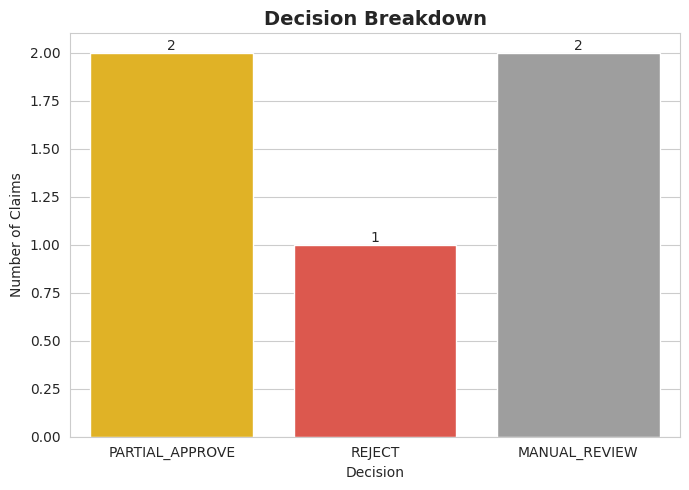

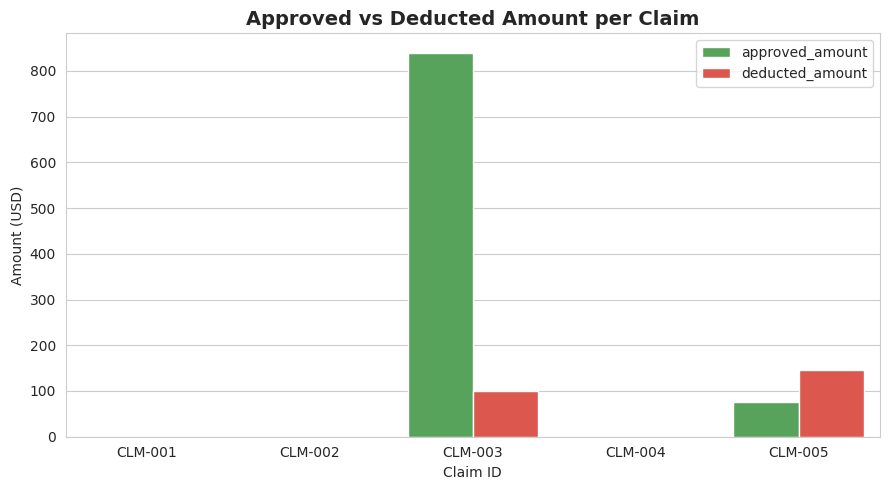

/tmp/ipykernel_811/3955650737.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=df, x="claim_id", y="confidence", palette="Blues_d")


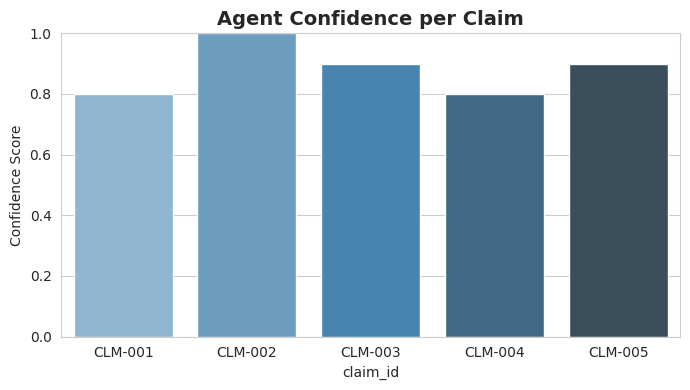

In [ ]:
df = pd.DataFrame(results)
df_display = df[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]]
df_display




# chart 1 decision breakdown

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
decision_order = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
colors = {"APPROVE": "#4CAF50", "PARTIAL_APPROVE": "#FFC107", "REJECT": "#F44336", "MANUAL_REVIEW": "#9E9E9E"}

ax = sns.countplot(
    data=df,
    x="decision",
    order=[d for d in decision_order if d in df["decision"].values],
    palette=[colors[d] for d in decision_order if d in df["decision"].values]
)
ax.set_title("Decision Breakdown", fontsize=14, fontweight="bold")
ax.set_xlabel("Decision")
ax.set_ylabel("Number of Claims")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("UI SS_1.png", dpi=150)
plt.show()


# chart 2:Approved vs deducted amount per claim

plt.figure(figsize=(9, 5))

df_melted = df.melt(
    id_vars="claim_id",
    value_vars=["approved_amount", "deducted_amount"],
    var_name="amount_type",
    value_name="amount"
)

ax2 = sns.barplot(
    data=df_melted,
    x="claim_id",
    y="amount",
    hue="amount_type",
    palette={"approved_amount": "#4CAF50", "deducted_amount": "#F44336"}
)
ax2.set_title("Approved vs Deducted Amount per Claim", fontsize=14, fontweight="bold")
ax2.set_xlabel("Claim ID")
ax2.set_ylabel("Amount (USD)")
ax2.legend(title="")

plt.tight_layout()
plt.savefig("UI SS_2.png", dpi=150)
plt.show()


# confidence overview

plt.figure(figsize=(7, 4))
ax3 = sns.barplot(data=df, x="claim_id", y="confidence", palette="Blues_d")
ax3.set_title("Agent Confidence per Claim", fontsize=14, fontweight="bold")
ax3.set_ylim(0, 1)
ax3.set_ylabel("Confidence Score")
plt.tight_layout()
plt.show()
